In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Unemployment in India.csv")

In [5]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [7]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [8]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [9]:
df = df.dropna()
df.isnull().sum()
# df.count()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64

In [10]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [11]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [12]:
df.columns = df.columns.str.strip()

In [13]:
avg_une = df["Estimated Unemployment Rate (%)"].mean()
print(avg_une)

11.787945945945946


In [14]:
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban


In [15]:
# Clean column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace('\xa0', ' ', regex=False)
df.columns = df.columns.str.replace('  ', ' ', regex=False)

# Convert numeric columns safely
numeric_cols = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")
df[numeric_cols]

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
0,3.65,11999139.0,43.24
1,3.05,11755881.0,42.05
2,3.75,12086707.0,43.50
3,3.32,12285693.0,43.97
4,5.17,12256762.0,44.68
...,...,...,...
749,7.55,10871168.0,44.09
750,6.67,10806105.0,43.34
751,15.63,9299466.0,41.20
752,15.22,9240903.0,40.67


In [16]:
area_summary = df.groupby("Area")[[
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]].mean()

area_summary = area_summary.round(2)
area_summary

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Area,,,
Rural,10.32,10192852.57,44.46
Urban,13.17,4388625.58,40.90


In [17]:
region_summary = df.groupby("Region")[[
    "Estimated Unemployment Rate (%)",
    "Estimated Labour Participation Rate (%)"
]].mean()

region_summary = region_summary.round(2).sort_values(
    by="Estimated Unemployment Rate (%)",
    ascending=False
)

region_summary

,Estimated Unemployment Rate (%),Estimated Labour Participation Rate (%)
Region,,
Tripura,28.35,61.82
Haryana,26.28,42.74
Jharkhand,20.58,41.67
Bihar,18.92,38.15
Himachal Pradesh,18.54,44.22
Delhi,16.50,38.93
Jammu & Kashmir,16.19,41.03
Chandigarh,15.99,39.34
Rajasthan,14.06,39.97


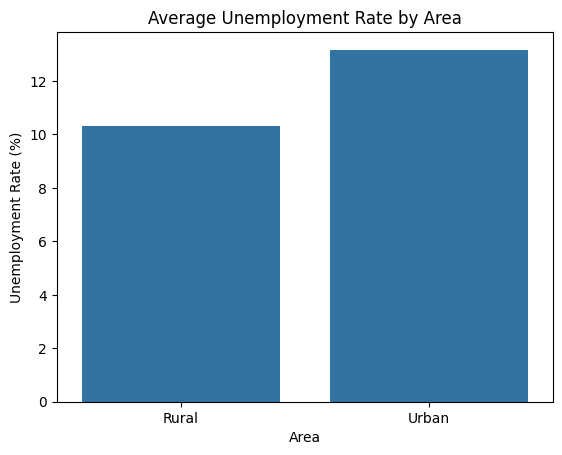

In [18]:
sns.barplot(
    data=area_summary,
    x="Area",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Average Unemployment Rate by Area")
plt.xlabel("Area")
plt.ylabel("Unemployment Rate (%)")
plt.show()

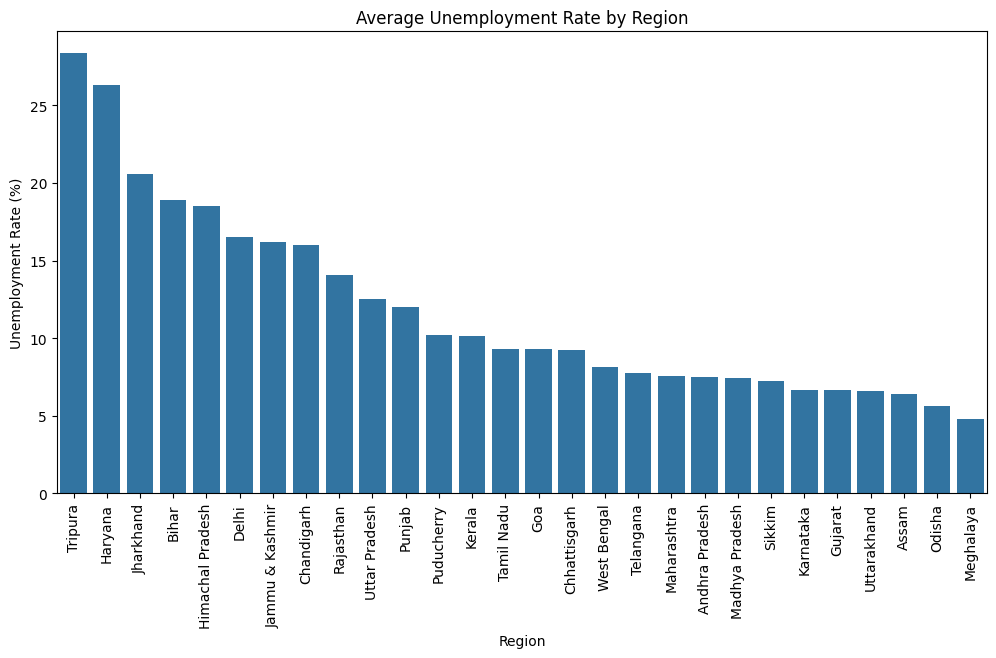

In [19]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=region_summary,
    x="Region",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.show()

In [20]:
df["Date"] = pd.to_datetime(df["Date"])

date_summary = df.groupby("Date")[[
    "Estimated Unemployment Rate (%)",
    "Estimated Labour Participation Rate (%)"
]].mean()

date_summary = date_summary.round(2)
date_summary

C:\Users\Dharm Maniya\AppData\Local\Temp\ipykernel_3724\222800678.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])


,Estimated Unemployment Rate (%),Estimated Labour Participation Rate (%)
Date,,
2019-05-31,8.87,43.90
2019-06-30,9.30,43.75
2019-07-31,9.03,43.71
2019-08-31,9.64,43.65
2019-09-30,9.05,44.30
2019-10-31,9.90,44.00
2019-11-30,9.87,44.11
2019-12-31,9.50,43.67
2020-01-31,9.95,44.05


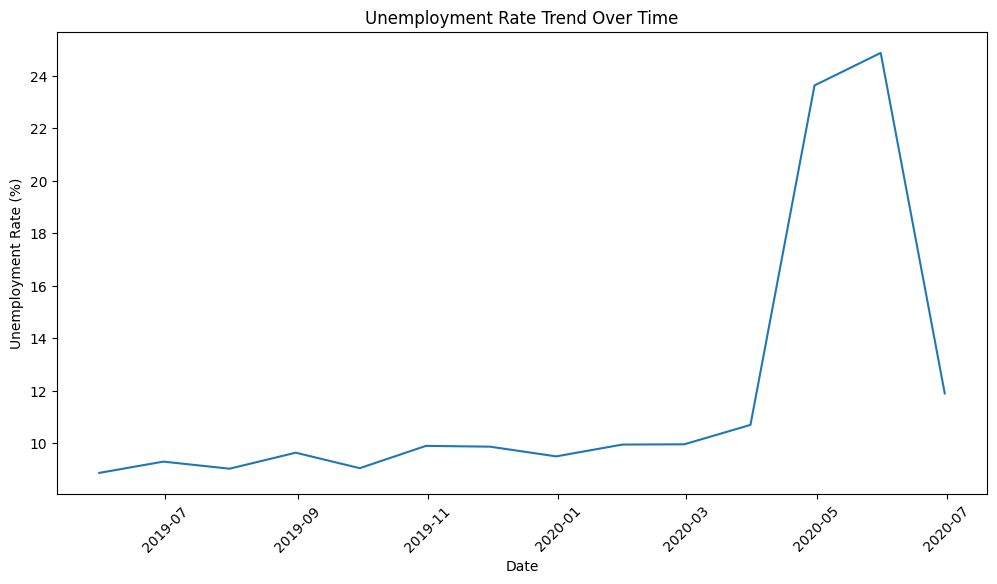

In [21]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=date_summary,
    x="Date",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Unemployment Rate Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [22]:
# Region with highest unemployment
highest_unemp_region = region_summary["Estimated Unemployment Rate (%)"].idxmax()
highest_unemp_value = region_summary["Estimated Unemployment Rate (%)"].max()

# Region with lowest unemployment
lowest_unemp_region = region_summary["Estimated Unemployment Rate (%)"].idxmin()
lowest_unemp_value = region_summary["Estimated Unemployment Rate (%)"].min()

print(f"""
The region with the highest average unemployment rate is {highest_unemp_region} with {highest_unemp_value:.2f}%.

The region with the lowest average unemployment rate is {lowest_unemp_region} with {lowest_unemp_value:.2f}%.

""")


The region with the highest average unemployment rate is Tripura with 28.35%.

The region with the lowest average unemployment rate is Meghalaya with 4.80%.


